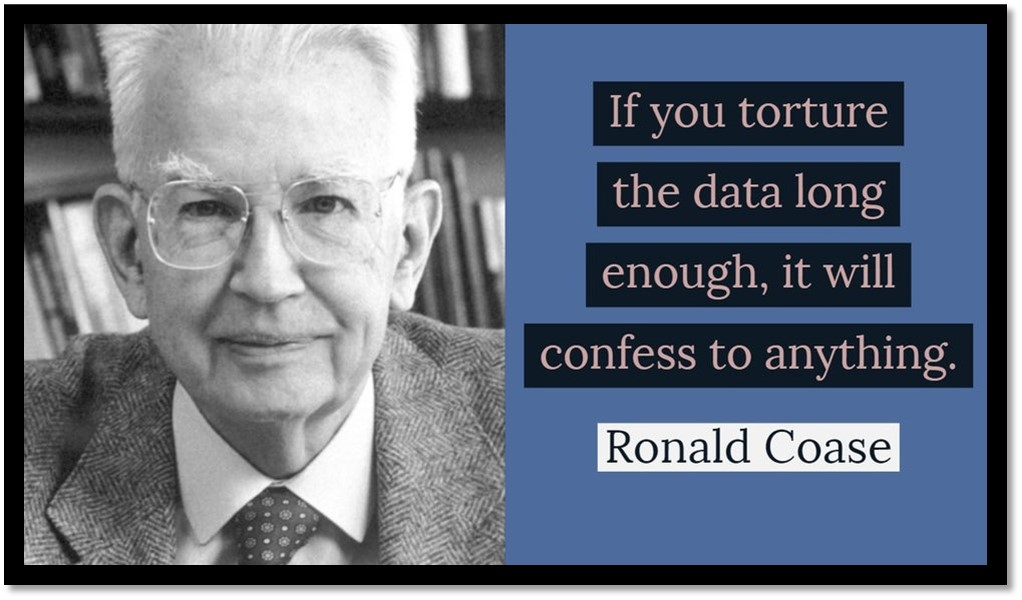<img src="images/data_transformation.jpg" width="700">

<h1><b>Table of Contents</b><span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Data-Transformation" data-toc-modified-id="Data-Transformation-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Data Transformation</a></span><ul class="toc-item"><li><span><a href="#Reading-data" data-toc-modified-id="Reading-data-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Reading data<a class="anchor" id="readingdata"></a></a></span></li><li><span><a href="#Handle-missing-values" data-toc-modified-id="Handle-missing-values-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Handle missing values</a></span><ul class="toc-item"><li><span><a href="#Replace-using-median" data-toc-modified-id="Replace-using-median-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Replace using median</a></span></li><li><span><a href="#Erase-non-important-feature" data-toc-modified-id="Erase-non-important-feature-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Erase non important feature</a></span></li><li><span><a href="#Replace-categorical-value-with-most-frequent-value" data-toc-modified-id="Replace-categorical-value-with-most-frequent-value-1.2.3"><span class="toc-item-num">1.2.3&nbsp;&nbsp;</span>Replace categorical value with most frequent value</a></span></li></ul></li><li><span><a href="#Data-skewness" data-toc-modified-id="Data-skewness-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Data skewness</a></span><ul class="toc-item"><li><span><a href="#Distribution-plots-of-the-data" data-toc-modified-id="Distribution-plots-of-the-data-1.3.1"><span class="toc-item-num">1.3.1&nbsp;&nbsp;</span>Distribution plots of the data</a></span></li><li><span><a href="#Handling-positively-skewed-cols" data-toc-modified-id="Handling-positively-skewed-cols-1.3.2"><span class="toc-item-num">1.3.2&nbsp;&nbsp;</span>Handling positively skewed cols</a></span><ul class="toc-item"><li><span><a href="#Applying-Square-root-transformation" data-toc-modified-id="Applying-Square-root-transformation-1.3.2.1"><span class="toc-item-num">1.3.2.1&nbsp;&nbsp;</span>Applying Square root transformation</a></span></li><li><span><a href="#Applying-logarithmic-transformation" data-toc-modified-id="Applying-logarithmic-transformation-1.3.2.2"><span class="toc-item-num">1.3.2.2&nbsp;&nbsp;</span>Applying logarithmic transformation</a></span></li></ul></li></ul></li><li><span><a href="#Detect-Outliers" data-toc-modified-id="Detect-Outliers-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Detect Outliers</a></span><ul class="toc-item"><li><span><a href="#Box-plots-of-the-data" data-toc-modified-id="Box-plots-of-the-data-1.4.1"><span class="toc-item-num">1.4.1&nbsp;&nbsp;</span>Box plots of the data</a></span></li><li><span><a href="#The-interquartile-range-(IQR)" data-toc-modified-id="The-interquartile-range-(IQR)-1.4.2"><span class="toc-item-num">1.4.2&nbsp;&nbsp;</span>The interquartile range (IQR)</a></span></li></ul></li><li><span><a href="#Encoding-features" data-toc-modified-id="Encoding-features-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Encoding features</a></span><ul class="toc-item"><li><span><a href="#Use-label-encoder-for-2-or-3-unique-features" data-toc-modified-id="Use-label-encoder-for-2-or-3-unique-features-1.5.1"><span class="toc-item-num">1.5.1&nbsp;&nbsp;</span>Use label encoder for 2 or 3 unique features</a></span></li><li><span><a href="#One-hot-encoder-for-the-rest" data-toc-modified-id="One-hot-encoder-for-the-rest-1.5.2"><span class="toc-item-num">1.5.2&nbsp;&nbsp;</span>One hot encoder for the rest</a></span></li></ul></li><li><span><a href="#Scaling-/-Normalizing" data-toc-modified-id="Scaling-/-Normalizing-1.6"><span class="toc-item-num">1.6&nbsp;&nbsp;</span>Scaling / Normalizing</a></span></li></ul></li></ul></div>

# **Data Transformation**

## **Libraries**

In [17]:
import pandas as pd
import math
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **1.1 Reading data**<a class="anchor" id="readingdata"></a>

Opción A => Leer un fichero local de tu ordenador desde Google Colab

In [18]:
#To read files from a Google Colab environment
from google.colab import files
import io

uploaded = files.upload()
uploaded

{}

Opción B => Leer de Drive (se debe aceptar permiso)

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
%cd /content/drive/My Drive/Colab Notebooks/

/content/drive/My Drive/Colab Notebooks


Leer el DataFrame

In [21]:
df = pd.read_csv('/content/drive/MyDrive/Archivos .csv/train.csv') # Replace with your path
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Let's view the columns we have

In [22]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## **1.2 Handle missing values**

<Axes: >

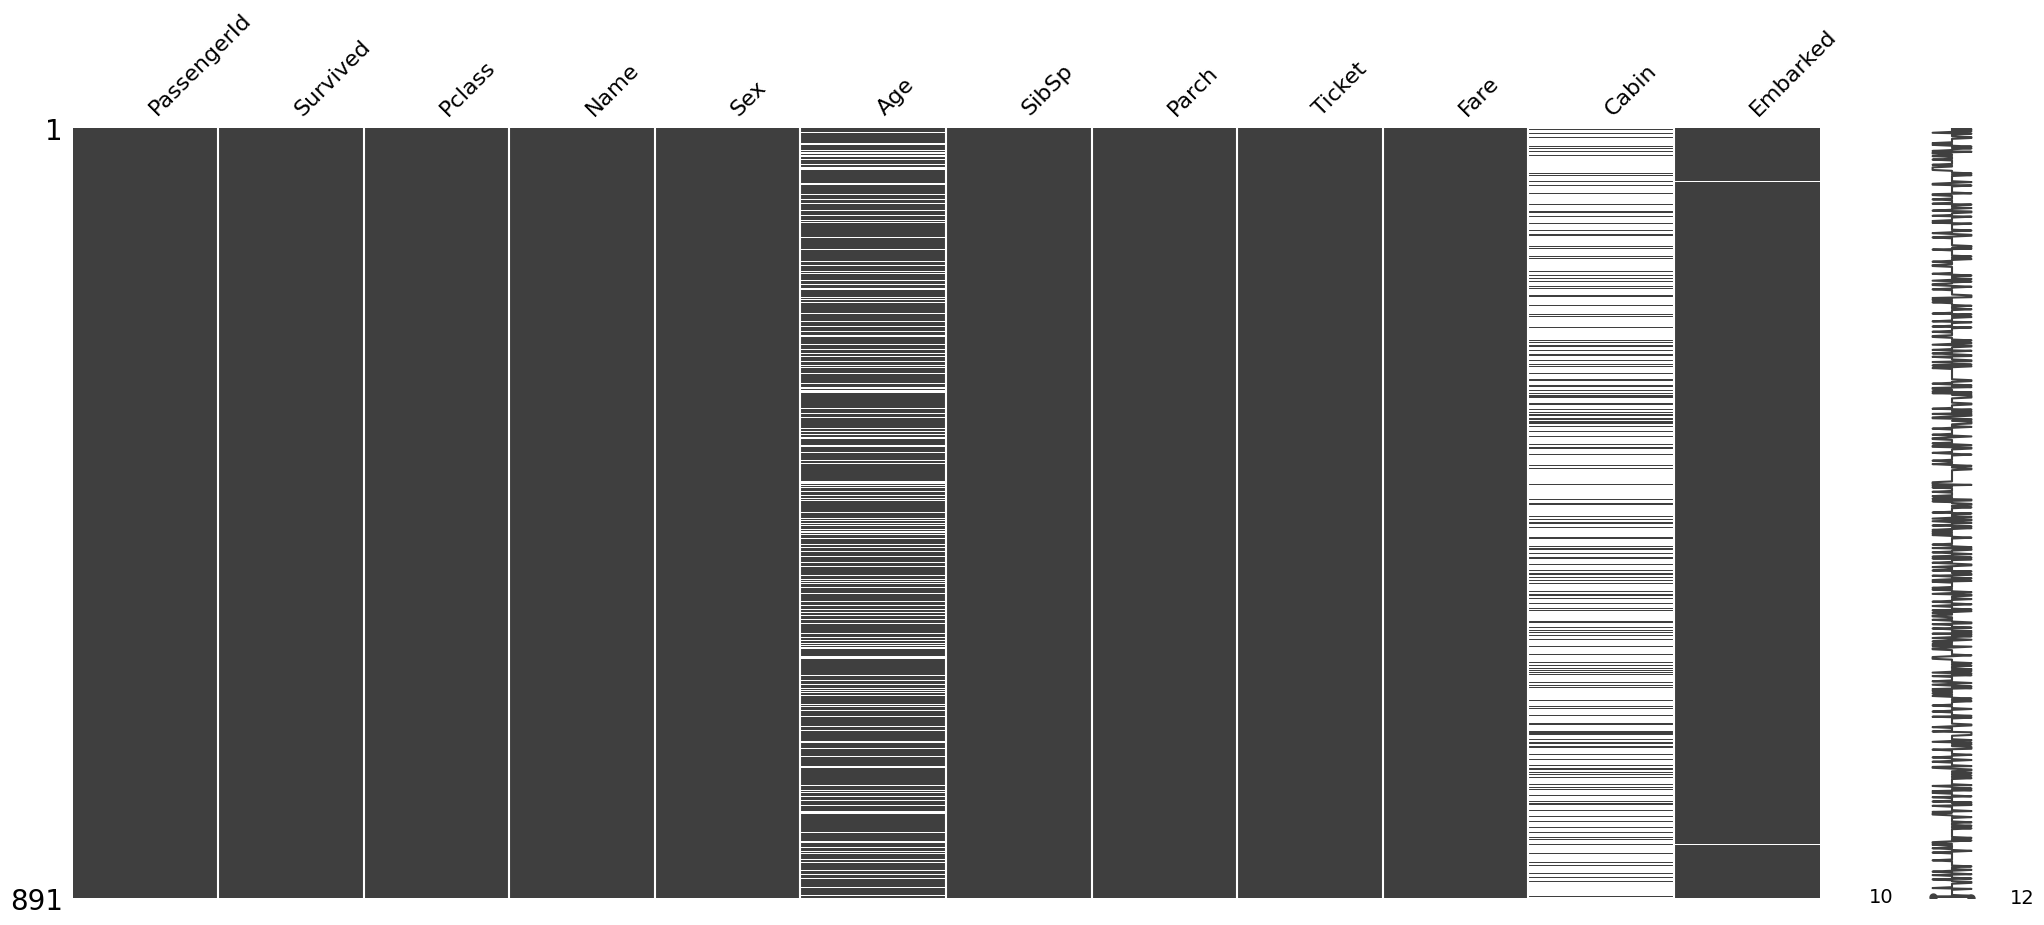

In [24]:
import missingno as msno

msno.matrix(df)

<Axes: >

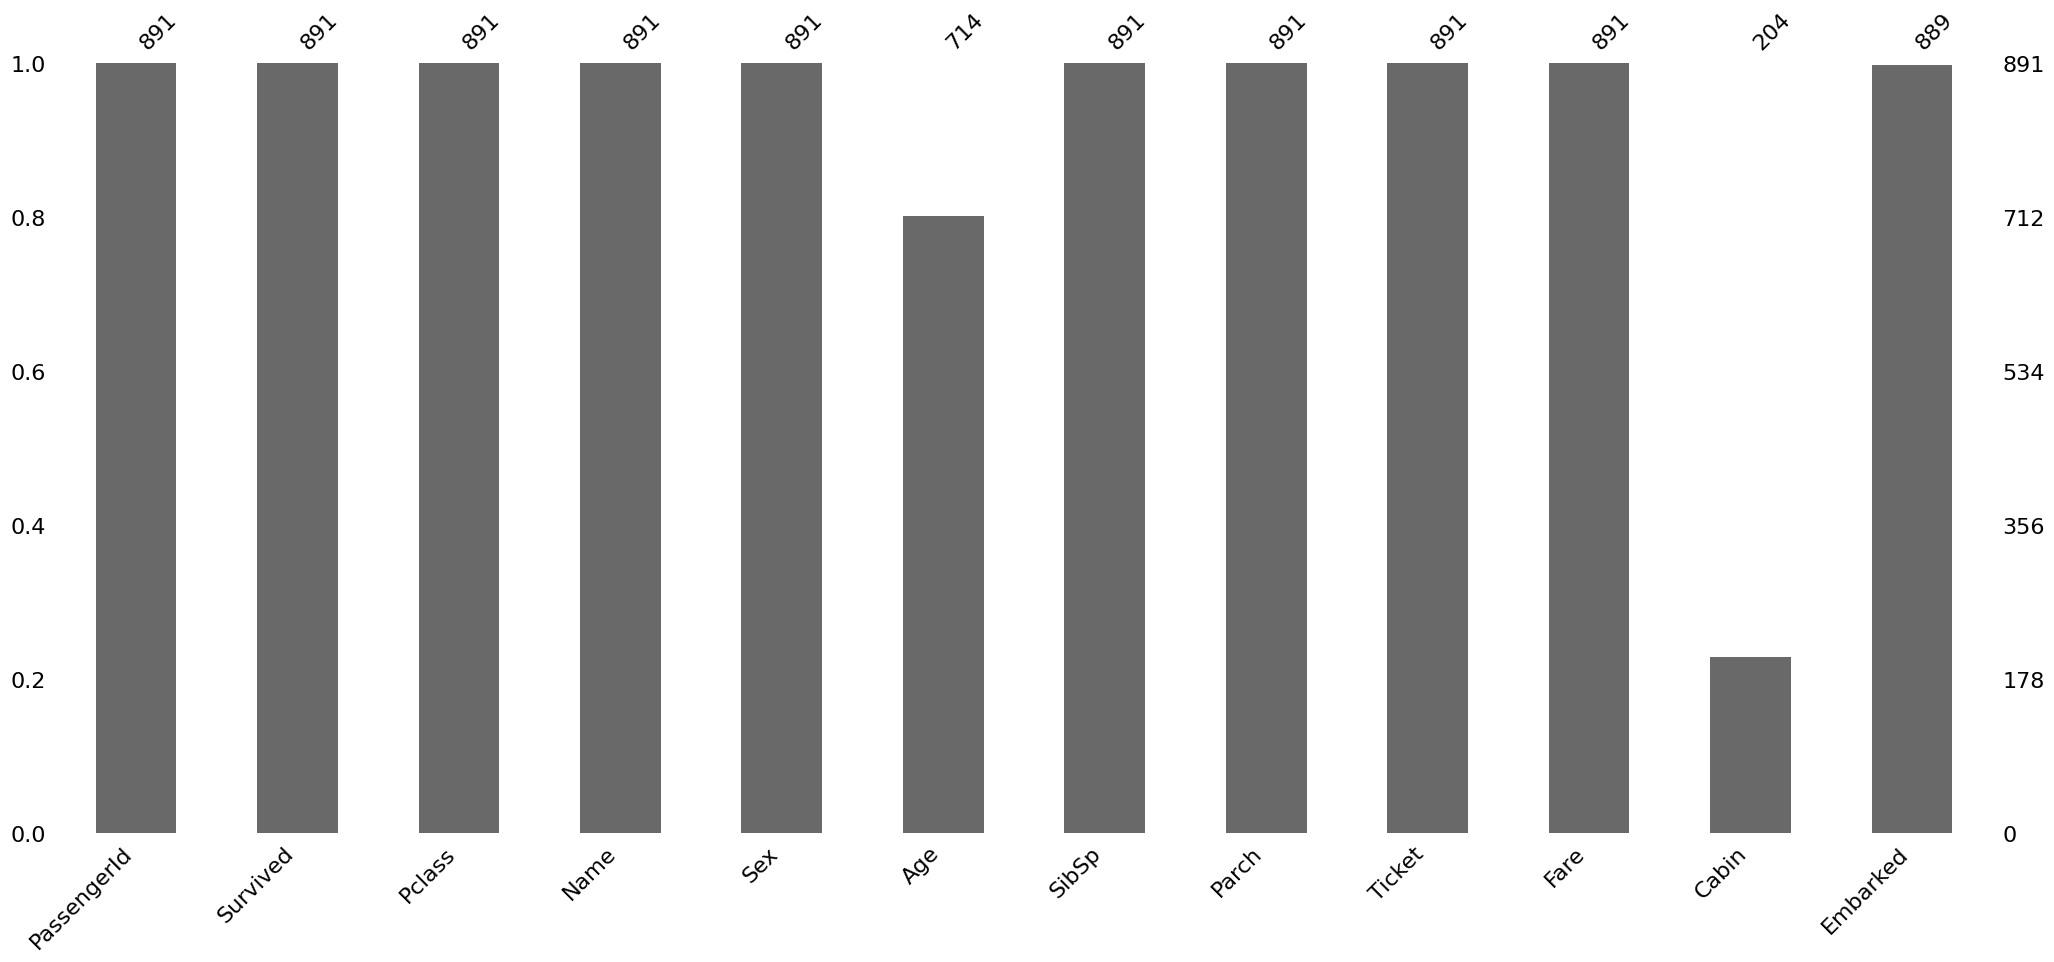

In [25]:
msno.bar(df)

Another way to view the missing values

In [26]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


As we can observe Age,Cabin and Embarked features contain missing values 177, 687 and 2 values to be exact.  
  
    
**Time to work**  
What can we apply for every case and why?  
Try to code it

In [27]:
#Your code

import pandas as pd

# Tratamiento de 'Embarked'
most_frequent_port = df['Embarked'].mode()[0]

# Rellenamos los valores nulos con la moda
df['Embarked'] = df['Embarked'].fillna(most_frequent_port)

# Tratamiento de 'Age'
# Calculamos la mediana de las edades
median_age = df['Age'].median()

# Rellenamos los valores nulos con la mediana
df['Age'] = df['Age'].fillna(median_age)

# Tratamiento de 'Cabin'
# Rellenamos los nulos con la letra 'U' (Unknown/Desconocido)
df['Cabin'] = df['Cabin'].fillna('U')

# Verificación final
# Comprobamos que ya no quedan valores nulos en estas columnas
print(df[['Age', 'Cabin', 'Embarked']].isnull().sum())

Age         0
Cabin       0
Embarked    0
dtype: int64


## **1.3 Data skewness**

### Distribution plots of the data

Text(0.5, 1.0, 'Distribution for every column')

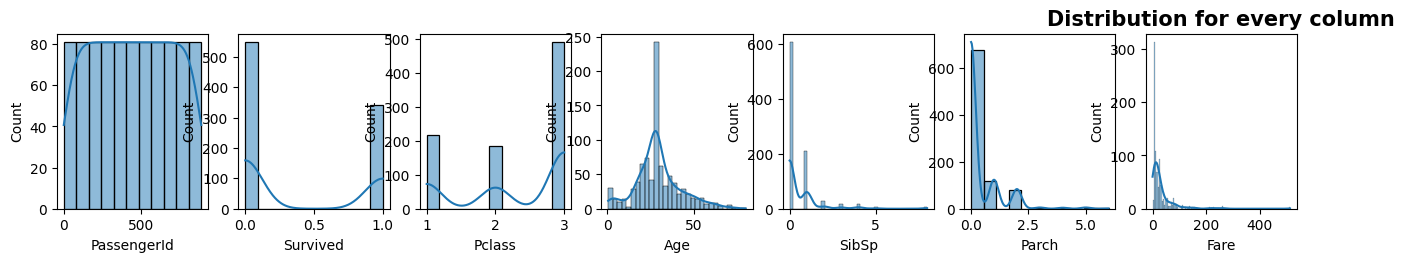

In [28]:
data_columns = df._get_numeric_data().columns.values
plot_columns = 7
number_of_columns = math.ceil(len(data_columns)/plot_columns)
number_of_rows = math.ceil((len(data_columns))/number_of_columns)

plt.figure(figsize=(16,5))

# plot distribution
for i in range(0, len(data_columns)):
    plt.subplot(number_of_columns + 1, number_of_rows, i+1)
    sns.histplot(df[data_columns[i]], kde=True)

plt.title('Distribution for every column', fontsize=15, fontweight='bold')


As we can observe in the above distribution graphs the majority of the features are far from the normal distribution.
Moreover, we can observe that some of the features have positive skewness (right) and there is not any negative skewness (left). In orther to achieve a normal distribution in these features we will use the next transformations:
* **Positive skewed features**:
       - Square root tranformation
       - Cube root transformation
       - Log transformation
* **Negative skewed features** (if there is):
        - Square transformation
        - Cube transformation



**Time to work**  
Which attributes need to apply a skewness process? Why?  
Try to code it


In [29]:
#Your code
# Filtramos solo las columnas numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculamos el sesgo (skewness)
skewness = df[numeric_cols].skew()

positively_skewed_cols = []
negatively_skewed_cols = []

# Definimos el umbral (0.75 suele ser la convención estándar)
umbral = 0.75

for col in numeric_cols:
    if skewness[col] > umbral:
        positively_skewed_cols.append(col)
    elif skewness[col] < -umbral:
        negatively_skewed_cols.append(col)

print("Positively skewed cols:", positively_skewed_cols)
print("Negatively skewed cols:", negatively_skewed_cols)

Positively skewed cols: ['SibSp', 'Parch', 'Fare']
Negatively skewed cols: []


### Handling positively/negatively skewed cols


In [44]:
#Your code

import numpy as np

# Transformación Logarítmica para sesgo positivo
# Usamos log1p para evitar errores con los valores de 0
for col in positively_skewed_cols:
    df[col] = np.log1p(df[col])

# Transformación al cuadrado para sesgo negativo
for col in negatively_skewed_cols:
    df[col] = np.square(df[col])

print("¡Transformaciones aplicadas!")
print("\nNuevo sesgo (skewness) en las columnas modificadas:")
print(df[positively_skewed_cols + negatively_skewed_cols].skew())

¡Transformaciones aplicadas!

Nuevo sesgo (skewness) en las columnas modificadas:
SibSp    1.661245
Parch    1.675439
Fare     0.394928
dtype: float64


### Results

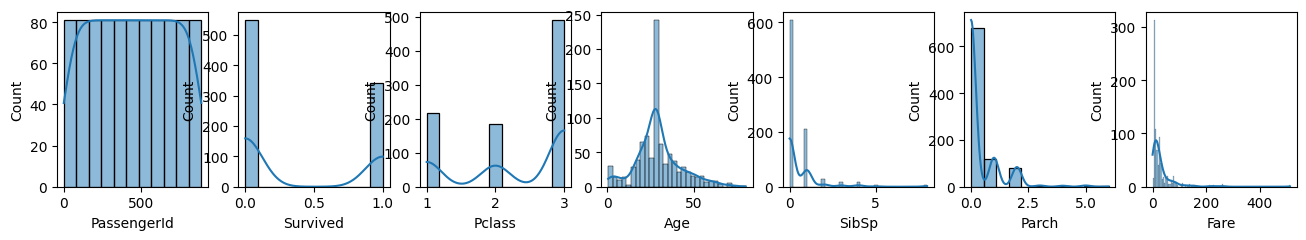

In [31]:
data_columns = df._get_numeric_data().columns.values
plot_columns = 7
number_of_columns = math.ceil(len(data_columns)/plot_columns)
number_of_rows = math.ceil((len(data_columns))/number_of_columns)

plt.figure(figsize=(16,5))

# plot distribution
for i in range(0, len(data_columns)):
    plt.subplot(number_of_columns + 1, number_of_rows, i+1)
    sns.histplot(df[data_columns[i]], kde=True)

## **1.4 Detect Outliers**

### Box plots of the data  
Show quartile distribution for every colum to detect outlier

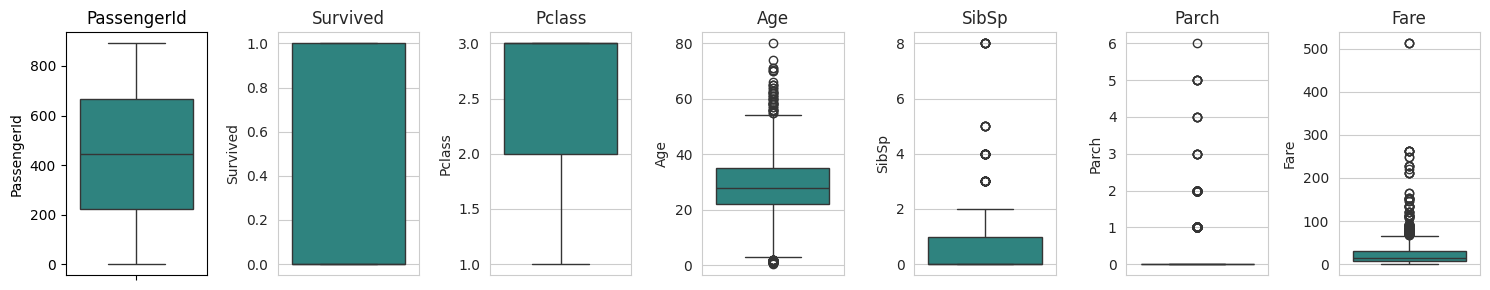

In [32]:
data_columns = df._get_numeric_data().columns.values
plot_columns = 7
number_of_columns = math.ceil(len(data_columns)/plot_columns)
number_of_rows = math.ceil((len(data_columns))/number_of_columns)

plt.figure(figsize=(15,3))
for i in range(0,len(data_columns)):
    plt.subplot(number_of_columns, number_of_rows, i+1)
    sns.set_style(style='whitegrid')
    sns.boxplot(data=df[data_columns[i]],palette='viridis',orient='v')
    plt.title(data_columns[i])
    plt.tight_layout()

**Time to work**  
Which attributes have outliers? Why?  


In [46]:
#Your code

# Definimos la lista que nos piden
outlier_cols = []

# Seleccionamos las columnas numéricas relevantes para evaluar
# (Asumiendo que 'PassengerId', 'Survived', 'Pclass', etc., no se consideran para outliers)
cols_to_check = ['Age', 'Fare', 'SibSp', 'Parch']

# Iteramos sobre las columnas para detectar si tienen outliers
for col in cols_to_check:
    # Calculamos los cuartiles y el Rango Intercuartílico (IQR)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definimos los límites inferior y superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Contamos cuántos registros están fuera de estos límites
    outliers_count = df[(df[col] < limite_inferior) | (df[col] > limite_superior)].shape[0]

    # Si la columna tiene al menos 1 outlier, la agregamos a nuestra lista
    if outliers_count > 0:
        outlier_cols.append(col)

# Comprobamos el resultado
print("Columnas detectadas con outliers:", outlier_cols)


Columnas detectadas con outliers: ['Age', 'Fare', 'SibSp', 'Parch']


### The interquartile range (IQR)
Is a measure of variability, based on dividing a data set into quartiles.

Quartiles divide a rank-ordered data set into four equal parts. The values that divide each part are called the first, second, and third quartiles; and they are denoted by Q1, Q2, and Q3, respectively.

* Q1 is the "middle" value in the first half of the rank-ordered data set.
* Q2 is the median value in the set.
* Q3 is the "middle" value in the second half of the rank-ordered data set.

The interquartile range (IQR) is equal to Q3 minus Q1.

   * **upperbound** = IQR * 1.5 + Q3
   * **lowerbound** = IQR * (-1.5) + Q1

If the data is higher than IQR*1.5 + Q3 or lower than the IQR * (-1.5) + Q1 it would be an outlier and we can replace it by the upper or lower bound.

In [47]:
for col in outlier_cols:
    quartile_1, quartile_3 = np.percentile(df[col], [25, 75])
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col]) #Replace the outlier with th upper_bound value
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

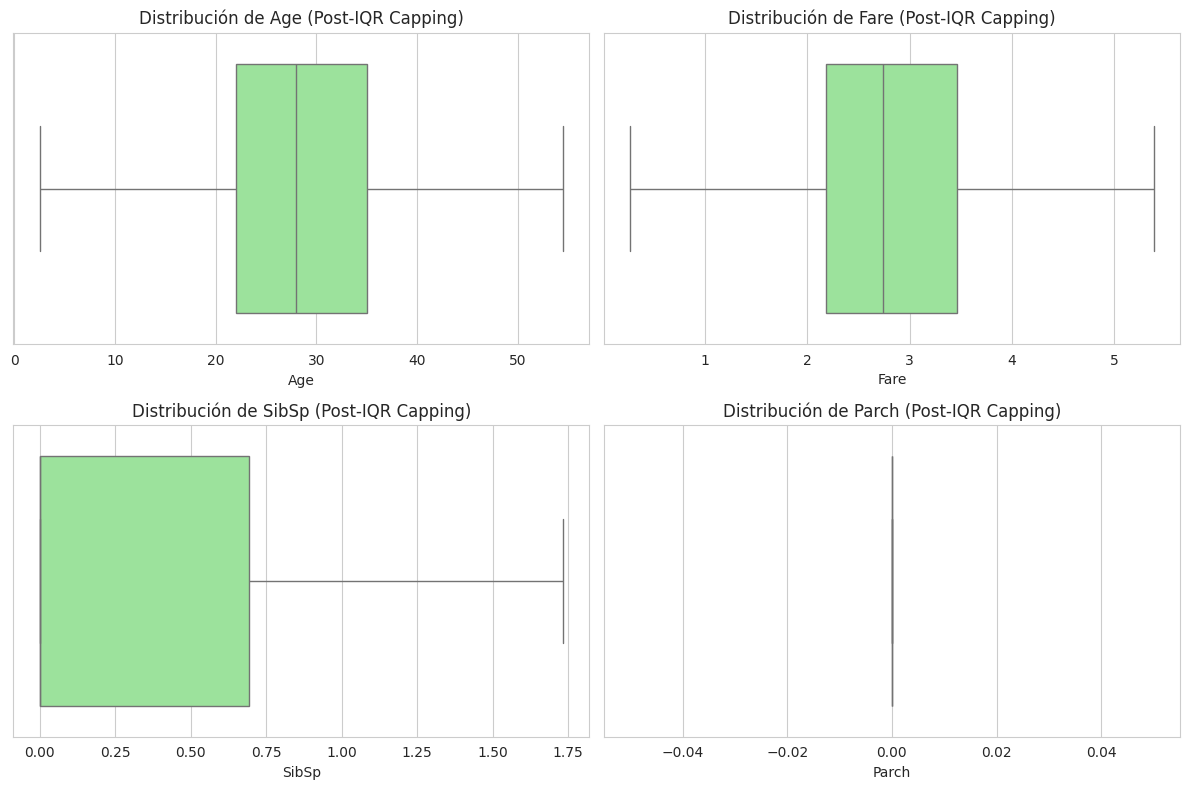

In [48]:
# Show again the features modified and its boxplot distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos dinámicamente el tamaño del grid (filas y columnas) para los gráficos
num_cols = len(outlier_cols)
filas = (num_cols + 1) // 2

plt.figure(figsize=(12, 4 * filas))

# Generamos un boxplot para cada columna en nuestra lista de outliers modificados
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(filas, 2, i)
    # Graficamos la columna
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Distribución de {col} (Post-IQR Capping)')

# Ajustamos el espaciado para que no se superpongan los títulos
plt.tight_layout()
plt.show()

## **1.5 Encoding features**  
Show categorical features (.info()) and describe them (.describe())

In [49]:
#Code it

# Filtramos para quedarnos solo con las columnas categóricas (texto)
categorical_features = df.select_dtypes(include=['object', 'category'])

# Mostramos la información estructural de estas columnas
print("Información de las variables categóricas:")
print("-" * 45)
categorical_features.info()

Información de las variables categóricas:
---------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      891 non-null    object
 1   Sex       891 non-null    object
 2   Ticket    891 non-null    object
 3   Cabin     891 non-null    object
 4   Embarked  891 non-null    object
dtypes: object(5)
memory usage: 34.9+ KB


In [50]:
#Code it

# Describimos las características categóricas
print("Descripción estadística de las variables categóricas:")
print("-" * 55)
categorical_features.describe()

Descripción estadística de las variables categóricas:
-------------------------------------------------------


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,148,3
top,"Dooley, Mr. Patrick",male,347082,U,S
freq,1,577,7,687,646


**Time to work**  
How transform every column? Why?  
Try to code

### Use label encoder for 2 or 3 unique features

In [51]:
# Your code

from sklearn.preprocessing import LabelEncoder

# Eliminamos las columnas irrelevantes como indica el texto
df = df.drop(['Name', 'Ticket'], axis=1)

# Inicializamos el codificador
le = LabelEncoder()

# Seleccionamos las columnas con 2 o 3 valores únicos
label_cols = ['Sex', 'Embarked']

# Aplicamos el Label Encoder
for col in label_cols:
    df[col] = le.fit_transform(df[col])

print(f"Label Encoding aplicado a: {label_cols}")
print("Columnas 'Name' y 'Ticket' eliminadas.")

Label Encoding aplicado a: ['Sex', 'Embarked']
Columnas 'Name' y 'Ticket' eliminadas.


### One hot encoder for the rest

In [52]:
# Your code

import pandas as pd

# Aplicamos One-Hot Encoding al resto de las columnas categóricas ('Cabin')
# Usamos drop_first=True para evitar la trampa de las variables ficticias (multicolinealidad)
df = pd.get_dummies(df, columns=['Cabin'], drop_first=True)

# Verificación final sugerida por tu imagen: "All the data is now numeric"
print("¡Codificación completa! Todas las características ahora son numéricas.")
print("-" * 60)
print(df.info())

¡Codificación completa! Todas las características ahora son numéricas.
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Columns: 156 entries, PassengerId to Cabin_U
dtypes: bool(147), float64(4), int64(5)
memory usage: 190.7 KB
None


We are not going to use these features (names and ticket), because they are too much and seem irrelevant.

All the data is now numeric.

## **1.6 Scaling / Normalizing**

In [53]:
from sklearn.preprocessing import MinMaxScaler

#Your code

# Inicializamos el escalador
scaler = MinMaxScaler()

# Ajustamos y transformamos todo el DataFrame
# Lo envolvemos en pd.DataFrame para mantener los nombres de las columnas y el índice
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Pequeña comprobación visual
print("¡Escalado completado! Rango actual de los datos:")
print(f"Mínimo global: {df.min().min()}")
print(f"Máximo global: {df.max().max()}")

¡Escalado completado! Rango actual de los datos:
Mínimo global: 0.0
Máximo global: 1.0000000000000002


<Axes: >

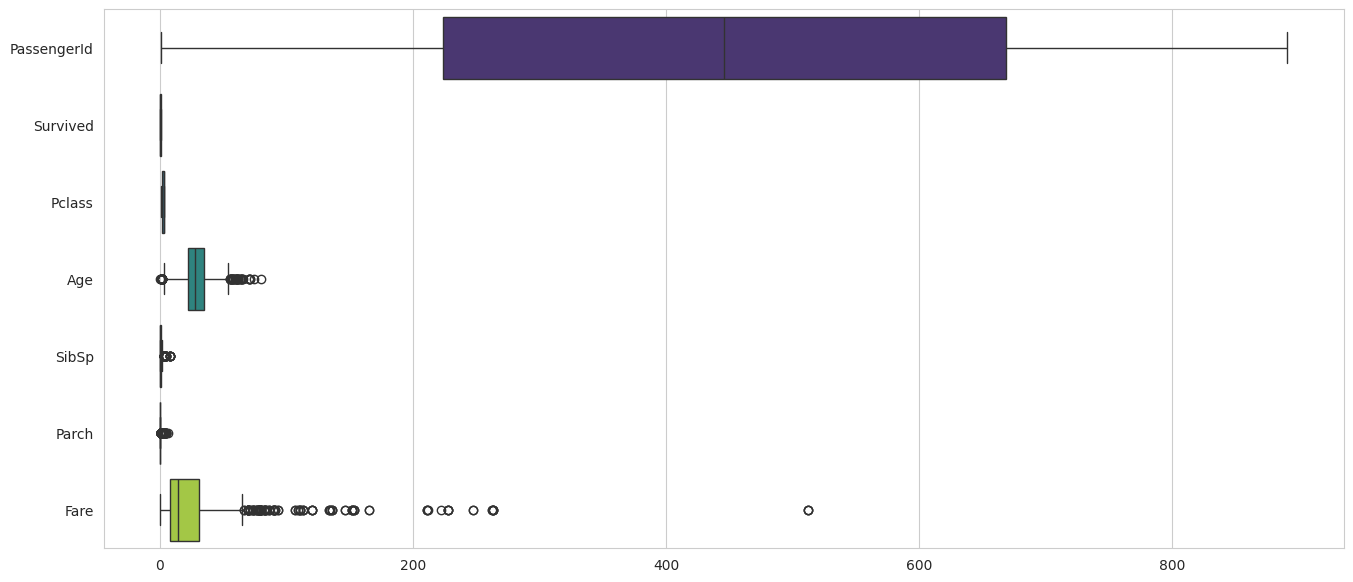

In [41]:
plt.figure(figsize=(16,7))
sns.boxplot(data=df.loc[:] , orient="h", palette="viridis")

Now we can see that our data is transformed:

    * It doens't have missing values.
    * The skewness has been removed.
    * The outliers has been removed.
    * The categorical features are encoded.
    * It is scaled from 0 to 1.

In [42]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S


Now we save the cleaned data to a file

In [54]:
df.to_csv('/content/drive/MyDrive/Archivos .csv/cleaned.csv',index=False)